In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Creat output file
if not os.path.exists('output'):
    os.makedirs('output')

# Seaborn Settings
sns.set_theme(style="darkgrid", palette='viridis')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

In [3]:
customer_data = pd.read_csv('data/shopping-data.csv')
print('\n--- the first 5 rows showing ---')
print(customer_data.head())

# Select Annual Income & Spending Score 
data = customer_data.iloc[:, 1:3].values


--- the first 5 rows showing ---
   CustomerID  Annual Income (k$)  Spending Score (1-100)
0           1                  15                      39
1           2                  15                      81
2           3                  16                       6
3           4                  16                      77
4           5                  17                      40


In [4]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

Clusters Centers (after scaling):
 [[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]
--------------------------------------------------
Clusters Labels  (first 10):
 [4 2 4 2 4 2 4 2 4 2]


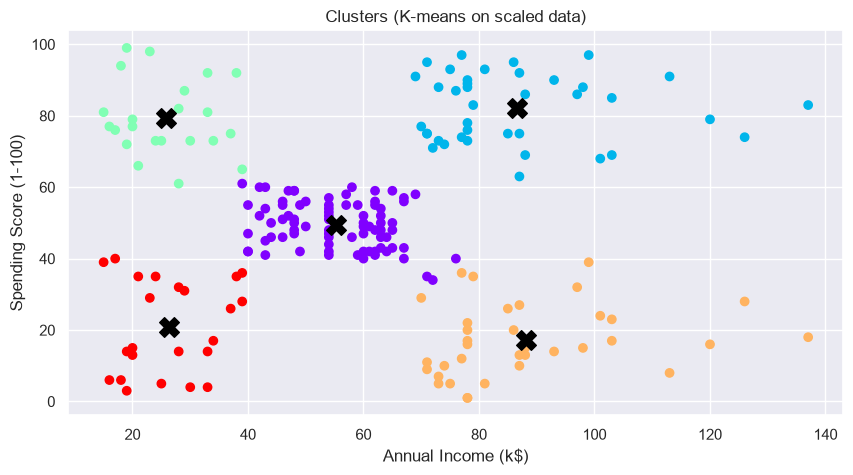


Fig 1: saved: output/01_Clusters.png

==========  K-means metrics (k=5) ==========
Silhouette Score        : 0.5547
Davies-Bouldin Index    : 0.5722
Calinski-Harabasz Index : 248.6493


In [5]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(data_scaled)

print('Clusters Centers (after scaling):\n', kmeans.cluster_centers_)
print('-' * 50)
print('Clusters Labels  (first 10):\n', kmeans.labels_[:10])

# draw clusters on acutal data(to anderstanding the clusters)
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(data[:, 0], data[:, 1], c=kmeans.labels_, cmap='rainbow')
plt.scatter(centers_original[:, 0], centers_original[:, 1],
            color='black', marker='X', s=200)
plt.title("Clusters (K-means on scaled data)")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.savefig('output/01_Clusters.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nFig 1: saved: output/01_Clusters.png")

# calculate evaluation metrics
sil = silhouette_score(data_scaled, kmeans.labels_)
db = davies_bouldin_score(data_scaled, kmeans.labels_)
ch = calinski_harabasz_score(data_scaled, kmeans.labels_)

print('\n==========  K-means metrics (k=5) ==========')
print(f'Silhouette Score        : {sil:.4f}')
print(f'Davies-Bouldin Index    : {db:.4f}')
print(f'Calinski-Harabasz Index : {ch:.4f}')

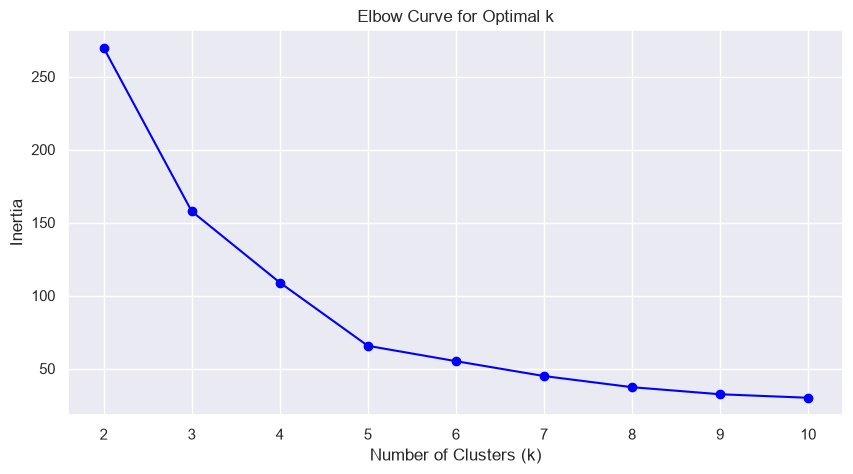


Fig 2: saved: output/02_Elbow.png


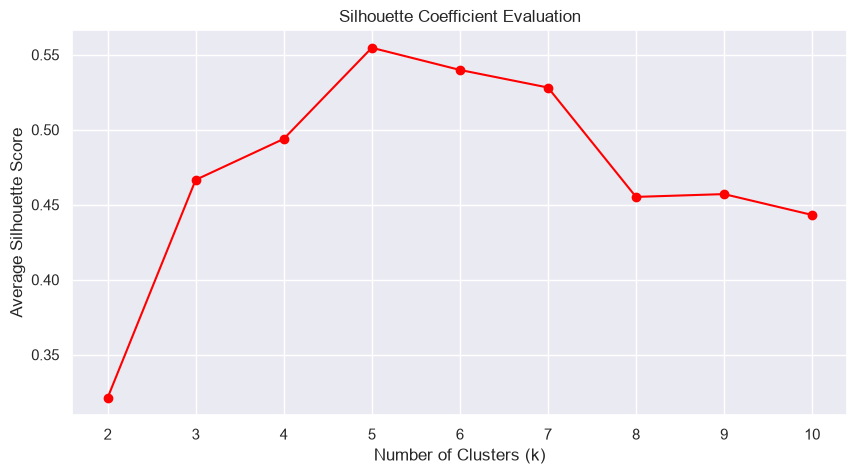

Fig 3: saved: output/03_Silhouette_vs_k.png


In [6]:
k_range = range(2, 11)

# 5-1. Elbow Curve (Inertia)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for Optimal k')
plt.savefig('output/02_Elbow.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nFig 2: saved: output/02_Elbow.png")

# 5-2. Silhouette Coefficient
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(data_scaled)
    sil_scores.append(silhouette_score(data_scaled, labels))

plt.figure()
plt.plot(k_range, sil_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Coefficient Evaluation')
plt.savefig('output/03_Silhouette_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 3: saved: output/03_Silhouette_vs_k.png")

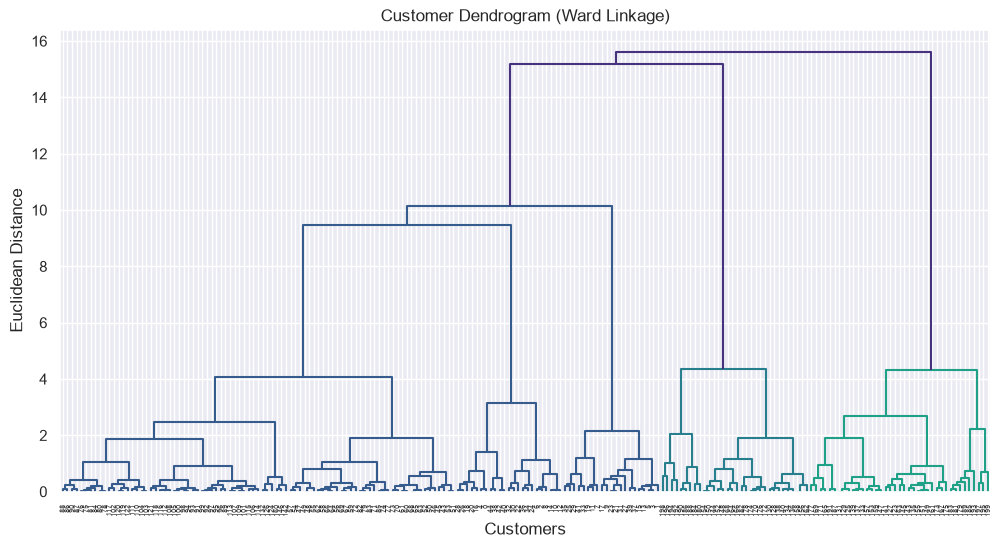

Fig 4: saved: output/04_Dendrogram.png

========== Agglomerative Metrics (k=5) ==========
Silhouette Score        : 0.5538
Davies-Bouldin Index    : 0.5779
Calinski-Harabasz Index : 244.4103


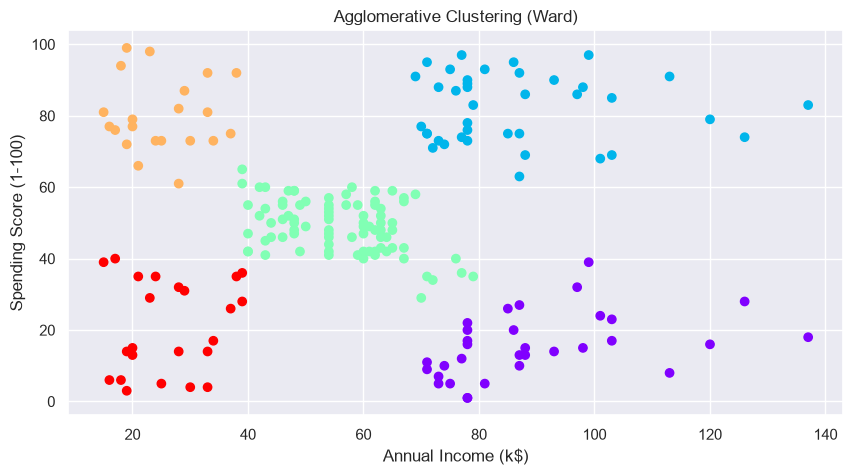

Fig 5: saved: output/05_Agglomerative_scatter.png


In [7]:
# 6-1. (Dendrogram)
linked = linkage(data_scaled, method='ward')
threshold = 0.7 * np.max(linked[:, 2])

plt.figure(figsize=(12, 6))
dendrogram(linked, color_threshold=threshold, orientation='top',
           distance_sort='descending', show_leaf_counts=True)
plt.title('Customer Dendrogram (Ward Linkage)')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.savefig('output/04_Dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 4: saved: output/04_Dendrogram.png")

# 6-2. Model fit & Evaluation
agg = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
labels_agg = agg.fit_predict(data_scaled)

sil_agg = silhouette_score(data_scaled, labels_agg)
db_agg = davies_bouldin_score(data_scaled, labels_agg)
ch_agg = calinski_harabasz_score(data_scaled, labels_agg)

print('\n========== Agglomerative Metrics (k=5) ==========')
print(f'Silhouette Score        : {sil_agg:.4f}')
print(f'Davies-Bouldin Index    : {db_agg:.4f}')
print(f'Calinski-Harabasz Index : {ch_agg:.4f}')

# draw Agglomerative Clustering plt.scatter(data[:, 0], data[:, 1], c=labels_agg, cmap='rainbow')
plt.figure()
plt.scatter(data[:,0], data[:,1], c=labels_agg, cmap='rainbow')
plt.title('Agglomerative Clustering (Ward)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.savefig('output/05_Agglomerative_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 5: saved: output/05_Agglomerative_scatter.png")

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in kf.split(data_scaled):
    km_cv = KMeans(n_clusters=5, random_state=42, n_init=10)
    km_cv.fit(data_scaled[train_idx])
    val_labels = km_cv.predict(data_scaled[val_idx])
    score = silhouette_score(data_scaled[val_idx], val_labels)
    cv_scores.append(score)

print('\n========== 5-Fold Cross-Validation ==========')
print(f'Silhouette Average : {np.mean(cv_scores):.4f}')
print(f'Standard Deviation : {np.std(cv_scores):.4f}')


========== 5-Fold Cross-Validation ==========
Silhouette Average : 0.5488
Standard Deviation : 0.0230


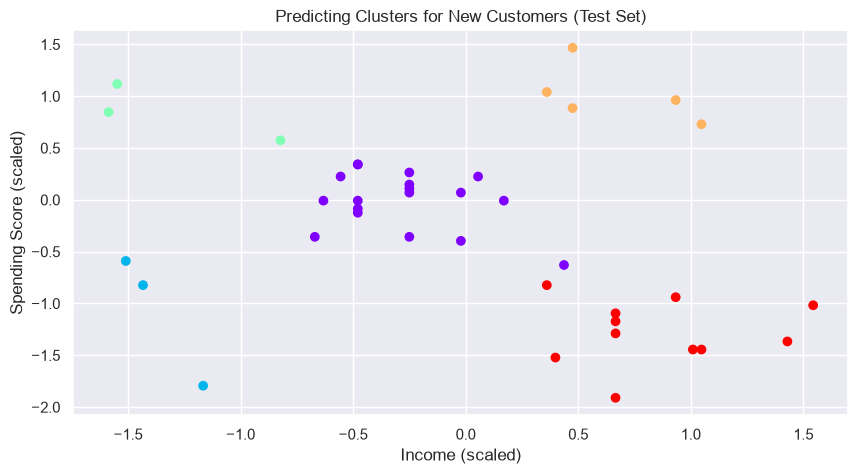

Fig 6: saved: output/06_TestSet_Predictions.png


In [9]:
X_train, X_test = train_test_split(data_scaled, test_size=0.2, random_state=42)

kmeans_train = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_train.fit(X_train)
preds_test = kmeans_train.predict(X_test)

plt.scatter(X_test[:, 0], X_test[:, 1], c=preds_test, cmap='rainbow')
plt.title('Predicting Clusters for New Customers (Test Set)')
plt.xlabel('Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.savefig('output/06_TestSet_Predictions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 6: saved: output/06_TestSet_Predictions.png")

In [10]:
print('\n' + '=' * 100)
print('Study Summary:')
print(f'- The optimal number of clusters: 5 ( based on Elbow & Dendrogram).')
print(f'- best model (K-means) achieved Silhouette = {sil:.4f}.')
print(f'- Model stability through cross-validation: Silhouette Average = {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}.')
print(f'- Saved {len(os.listdir("output"))} Charts in File output/.')
print('=' * 100)


Study Summary:
- The optimal number of clusters: 5 ( based on Elbow & Dendrogram).
- best model (K-means) achieved Silhouette = 0.5547.
- Model stability through cross-validation: Silhouette Average = 0.5488 ± 0.0230.
- Saved 10 Charts in File output/.



Generate & Saving in: 1000 data/synthetic_10000_customers.csv


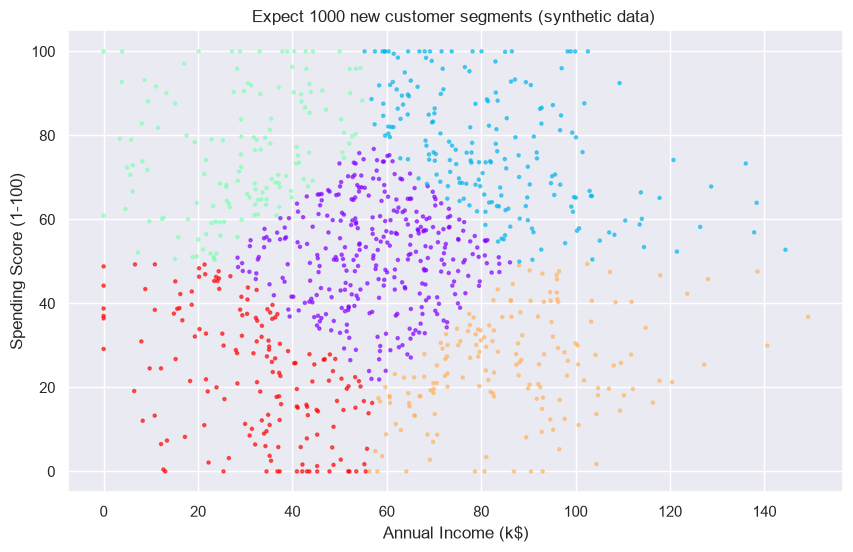

Fig 8: saved: output/08_Synthetic_Prediction.png

Distribution of structural customers across the five clusters:
  Cluster 0: 330 Customer (33.0%)
  Cluster 1: 197 Customer (19.7%)
  Cluster 2: 144 Customer (14.4%)
  Cluster 3: 166 Customer (16.6%)
  Cluster 4: 163 Customer (16.3%)


In [ ]:
# =============================================================================================================
#              Testing the model on large synthetic datasets (simulating 1000 new customers)
# =============================================================================================================

# 1.mean and standard deviation --> original data (for the same distribution)
mean_income = np.mean(data[:, 0])
std_income = np.std(data[:, 0])
mean_spending = np.mean(data[:, 1])
std_spending = np.std(data[:, 1])

# 2.Generate 1000 new customers
n_synthetic = 1000
syn_income = np.random.normal(mean_income, std_income, n_synthetic)
syn_spending = np.random.normal(mean_spending, std_spending, n_synthetic)

# 3. Trim the values ​​to keep them within a logical range (income 0-150, spending 0-100).
syn_income = np.clip(syn_income, 0, 150)
syn_spending = np.clip(syn_spending, 0, 100)

# 4. Merge them into an array with the same format as the original data.
synthetic_data = np.column_stack((syn_income, syn_spending))

# 5. Data standardization using the same trained StandardScaler
synthetic_scaled = scaler.transform(synthetic_data)

# 6. Predicting the classification of new customers using a trained K-means model
synthetic_labels = kmeans.predict(synthetic_scaled)

# 7. New Data Saving
synthetic_df = pd.DataFrame(synthetic_data, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
synthetic_df.to_csv('data/synthetic_1000_customers.csv', index=False)
print(f"\nGenerate & Saving in: {n_synthetic} data/synthetic_1000_customers.csv")

# 8. New installation customer distribution chart
plt.figure(figsize=(10, 6))
plt.scatter(synthetic_data[:, 0], synthetic_data[:, 1], c=synthetic_labels, cmap='rainbow', s=5, alpha=0.6)
plt.title(f"Expect {n_synthetic} new customer segments (synthetic data) ")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.savefig('output/08_Synthetic_Prediction.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 8: saved: output/08_Synthetic_Prediction.png")

# 9. Print a quick statistic on the distribution of new customers across segments
unique, counts = np.unique(synthetic_labels, return_counts=True)
print("\nDistribution of structural customers across the five clusters:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} Customer ({count/n_synthetic*100:.1f}%)")

In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Original Data Loading
customer_data = pd.read_csv('data/shopping-data.csv')
data = customer_data.iloc[:, 1:3].values

# mean and standard deviation --> original data
mean_income = np.mean(data[:, 0])
std_income = np.std(data[:, 0])
mean_spending = np.mean(data[:, 1])
std_spending = np.std(data[:, 1])

# Generate 10,000 new customers
n_new_customers = 1000

# Randomly generate new income and spending scores(same Distrebution)
new_income = np.random.normal(mean_income, std_income, n_new_customers)
new_spending = np.random.normal(mean_spending, std_spending, n_new_customers)

# the values ​​to keep them within a logical range (income 0-150, spending 0-100).
new_income = np.clip(new_income, 0, 150)
new_spending = np.clip(new_spending, 0, 100)

# Creat new DataFrame 
new_customers = pd.DataFrame({
    'Annual Income (k$)': new_income.astype(int),
    'Spending Score (1-100)': new_spending.astype(int)
})

# New data Saving
new_customers.to_csv('data/large_shopping_data.csv', index=False)
print(f"Generated {n_new_customers} New Customers")

Generated 1000 New Customers


New Customer Ratings (Top 10): [0 4 0 4 3 3 3 2 4 2]


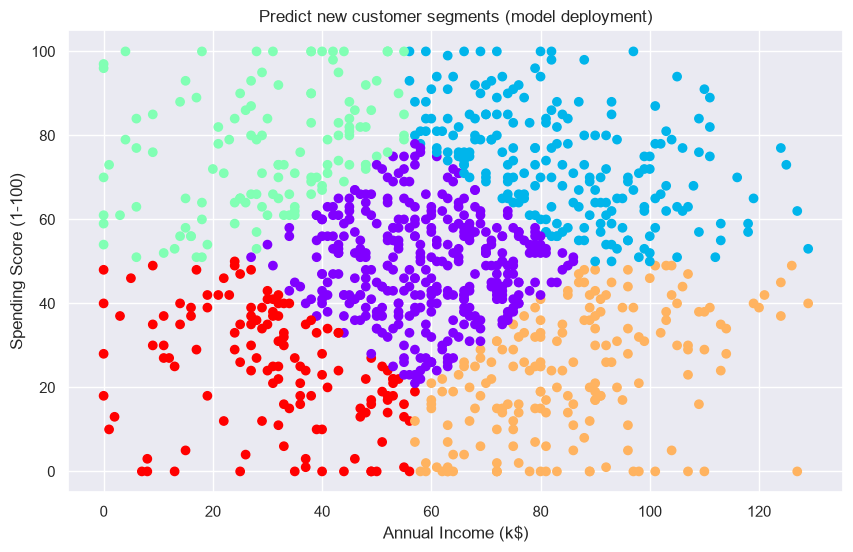

Fig 8: saved: output/08_New_Customers_Prediction.png


In [15]:
# ================================================================
# Testing the model on large synthetic datasets (Deployment)
# ================================================================

# 1.Data Loading
new_data_raw = pd.read_csv('data/large_shopping_data.csv')

# 2. Select Annual Income & Spending Score columns
new_data = new_data_raw.iloc[:, 0:2].values 

# 3. Data standardization using the same trained StandardScaler
new_data_scaled = scaler.transform(new_data) 

# 4. Predicting the classification of new customers using a trained (kmeans)
predictions_new = kmeans.predict(new_data_scaled)

# 5. Print the first 10 classifications
print("New Customer Ratings (Top 10):", predictions_new[:10])

# Ploting the data 
plt.figure(figsize=(10, 6))
plt.scatter(new_data[:, 0], new_data[:, 1], c=predictions_new, cmap='rainbow')
plt.title("Predict new customer segments (model deployment)")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.savefig('output/08_New_Customers_Prediction.png', dpi=300, bbox_inches='tight')
plt.show()
print("Fig 8: saved: output/08_New_Customers_Prediction.png")